<a href="https://colab.research.google.com/github/Yaqiao-chi-helen/Forecasting-team4/blob/main/notebooks/Model_Development_XGBoost_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost Model - Bhumika

In [130]:
import pandas as pd


In [131]:
df = pd.read_csv('/content/PJME_hourly_cleaned.csv')

In [132]:
df.head()


,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


In [133]:
df.shape

(145392, 2)

In [134]:
df.columns

Index(['Datetime', 'PJME_MW'], dtype='object')

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145392 entries, 0 to 145391
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145392 non-null  object 
 1   PJME_MW   145392 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [136]:
df.isnull().sum()

,0
Datetime,0
PJME_MW,0


In [137]:
df.duplicated().sum()

np.int64(0)

In [138]:
df.describe()

,PJME_MW
count,145392.000000
mean,32078.930711
std,6464.279302
min,14544.000000
25%,27571.000000
50%,31420.000000
75%,35647.000000
max,62009.000000


In [139]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [140]:
df['Datetime'] = pd.to_datetime(df['Datetime'], dayfirst=True)

In [141]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145392 entries, 0 to 145391
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145392 non-null  datetime64[ns]
 1   PJME_MW   145392 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


In [142]:
df['Datetime'].head()

,Datetime
0,2002-01-01 01:00:00
1,2002-01-01 02:00:00
2,2002-01-01 03:00:00
3,2002-01-01 04:00:00
4,2002-01-01 05:00:00


In [143]:
print("Start date:", df['Datetime'].min())
print("End date:", df['Datetime'].max())

Start date: 2002-01-01 01:00:00
End date: 2018-08-03 00:00:00


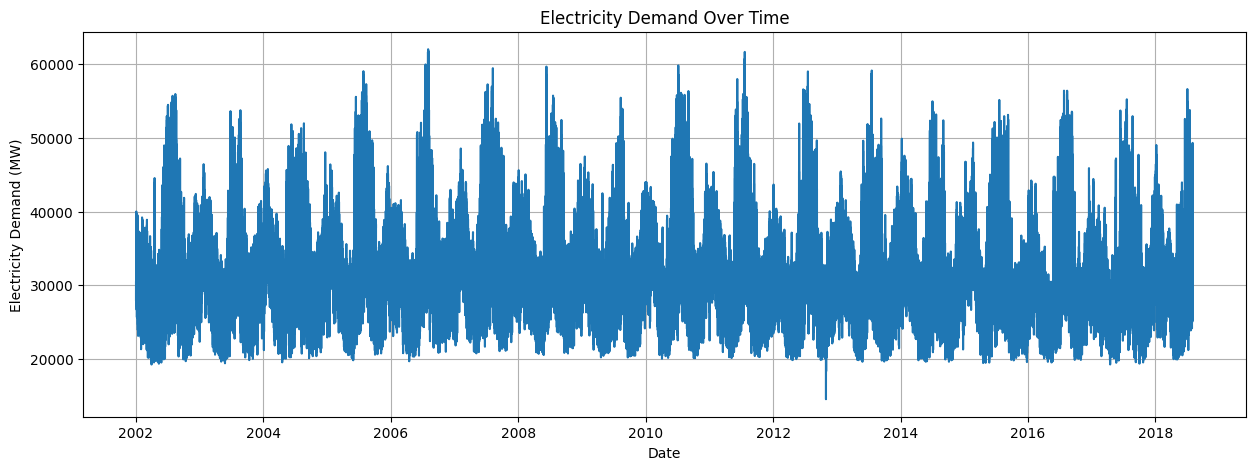

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(df['Datetime'], df['PJME_MW'])

plt.title('Electricity Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Electricity Demand (MW)')

plt.grid(True)
plt.show()

In [145]:
df['Hour'] = df['Datetime'].dt.hour

In [146]:
df[['Datetime', 'Hour']].head(10)

,Datetime,Hour
0,2002-01-01 01:00:00,1
1,2002-01-01 02:00:00,2
2,2002-01-01 03:00:00,3
3,2002-01-01 04:00:00,4
4,2002-01-01 05:00:00,5
5,2002-01-01 06:00:00,6
6,2002-01-01 07:00:00,7
7,2002-01-01 08:00:00,8
8,2002-01-01 09:00:00,9
9,2002-01-01 10:00:00,10


In [147]:
df['Day'] = df['Datetime'].dt.day

In [148]:
df[['Datetime', 'Hour', 'Day']].head(10)

,Datetime,Hour,Day
0,2002-01-01 01:00:00,1,1
1,2002-01-01 02:00:00,2,1
2,2002-01-01 03:00:00,3,1
3,2002-01-01 04:00:00,4,1
4,2002-01-01 05:00:00,5,1
5,2002-01-01 06:00:00,6,1
6,2002-01-01 07:00:00,7,1
7,2002-01-01 08:00:00,8,1
8,2002-01-01 09:00:00,9,1
9,2002-01-01 10:00:00,10,1


In [149]:
df['Month'] = df['Datetime'].dt.month

In [150]:
df[['Datetime', 'Hour', 'Day', 'Month']].head(10)

,Datetime,Hour,Day,Month
0,2002-01-01 01:00:00,1,1,1
1,2002-01-01 02:00:00,2,1,1
2,2002-01-01 03:00:00,3,1,1
3,2002-01-01 04:00:00,4,1,1
4,2002-01-01 05:00:00,5,1,1
5,2002-01-01 06:00:00,6,1,1
6,2002-01-01 07:00:00,7,1,1
7,2002-01-01 08:00:00,8,1,1
8,2002-01-01 09:00:00,9,1,1
9,2002-01-01 10:00:00,10,1,1


In [151]:
df['DayOfWeek'] = df['Datetime'].dt.dayofweek

In [152]:
df[['Datetime', 'DayOfWeek']].head(10)

,Datetime,DayOfWeek
0,2002-01-01 01:00:00,1
1,2002-01-01 02:00:00,1
2,2002-01-01 03:00:00,1
3,2002-01-01 04:00:00,1
4,2002-01-01 05:00:00,1
5,2002-01-01 06:00:00,1
6,2002-01-01 07:00:00,1
7,2002-01-01 08:00:00,1
8,2002-01-01 09:00:00,1
9,2002-01-01 10:00:00,1


In [153]:
print("hello world")

hello world


In [154]:
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

In [155]:
df.head(10)

,Datetime,PJME_MW,Hour,Day,Month,DayOfWeek,IsWeekend
0,2002-01-01 01:00:00,30393.0,1,1,1,1,0
1,2002-01-01 02:00:00,29265.0,2,1,1,1,0
2,2002-01-01 03:00:00,28357.0,3,1,1,1,0
3,2002-01-01 04:00:00,27899.0,4,1,1,1,0
4,2002-01-01 05:00:00,28057.0,5,1,1,1,0
5,2002-01-01 06:00:00,28654.0,6,1,1,1,0
6,2002-01-01 07:00:00,29308.0,7,1,1,1,0
7,2002-01-01 08:00:00,29595.0,8,1,1,1,0
8,2002-01-01 09:00:00,29943.0,9,1,1,1,0
9,2002-01-01 10:00:00,30692.0,10,1,1,1,0


In [156]:
df[['Datetime', 'PJME_MW', 'Hour', 'Day', 'Month', 'DayOfWeek', 'IsWeekend']].head(10)

,Datetime,PJME_MW,Hour,Day,Month,DayOfWeek,IsWeekend
0,2002-01-01 01:00:00,30393.0,1,1,1,1,0
1,2002-01-01 02:00:00,29265.0,2,1,1,1,0
2,2002-01-01 03:00:00,28357.0,3,1,1,1,0
3,2002-01-01 04:00:00,27899.0,4,1,1,1,0
4,2002-01-01 05:00:00,28057.0,5,1,1,1,0
5,2002-01-01 06:00:00,28654.0,6,1,1,1,0
6,2002-01-01 07:00:00,29308.0,7,1,1,1,0
7,2002-01-01 08:00:00,29595.0,8,1,1,1,0
8,2002-01-01 09:00:00,29943.0,9,1,1,1,0
9,2002-01-01 10:00:00,30692.0,10,1,1,1,0


In [157]:
df['Lag_1h'] = df['PJME_MW'].shift(1)

In [158]:
df[['Datetime', 'PJME_MW', 'Lag_1h']].head(10)

,Datetime,PJME_MW,Lag_1h
0,2002-01-01 01:00:00,30393.0,NaN
1,2002-01-01 02:00:00,29265.0,30393.0
2,2002-01-01 03:00:00,28357.0,29265.0
3,2002-01-01 04:00:00,27899.0,28357.0
4,2002-01-01 05:00:00,28057.0,27899.0
5,2002-01-01 06:00:00,28654.0,28057.0
6,2002-01-01 07:00:00,29308.0,28654.0
7,2002-01-01 08:00:00,29595.0,29308.0
8,2002-01-01 09:00:00,29943.0,29595.0
9,2002-01-01 10:00:00,30692.0,29943.0


In [159]:
df['Lag_24h'] = df['PJME_MW'].shift(24)

In [160]:
df['Lag_168h'] = df['PJME_MW'].shift(168)

In [161]:
df[['Datetime', 'PJME_MW', 'Lag_1h', 'Lag_24h', 'Lag_168h']].head(180)

,Datetime,PJME_MW,Lag_1h,Lag_24h,Lag_168h
0,2002-01-01 01:00:00,30393.0,NaN,NaN,NaN
1,2002-01-01 02:00:00,29265.0,30393.0,NaN,NaN
2,2002-01-01 03:00:00,28357.0,29265.0,NaN,NaN
3,2002-01-01 04:00:00,27899.0,28357.0,NaN,NaN
4,2002-01-01 05:00:00,28057.0,27899.0,NaN,NaN
...,...,...,...,...,...
175,2002-01-08 08:00:00,37841.0,35335.0,34678.0,29595.0
176,2002-01-08 09:00:00,37417.0,37841.0,35349.0,29943.0
177,2002-01-08 10:00:00,36824.0,37417.0,35542.0,30692.0
178,2002-01-08 11:00:00,36504.0,36824.0,35857.0,31395.0


In [102]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [103]:
df.isnull().sum()

,0
Datetime,0
PJME_MW,0
Hour,0
Day,0
Month,0
DayOfWeek,0
IsWeekend,0
Lag_1h,1
Lag_24h,24
Lag_168h,168


In [104]:
df = df.dropna().reset_index(drop=True)

In [105]:
df.shape

(145224, 10)

In [106]:
df.isnull().sum()

,0
Datetime,0
PJME_MW,0
Hour,0
Day,0
Month,0
DayOfWeek,0
IsWeekend,0
Lag_1h,0
Lag_24h,0
Lag_168h,0


In [107]:
df.isnull().sum()

,0
Datetime,0
PJME_MW,0
Hour,0
Day,0
Month,0
DayOfWeek,0
IsWeekend,0
Lag_1h,0
Lag_24h,0
Lag_168h,0


In [108]:
df = df.dropna().reset_index(drop=True)

In [109]:
df.shape

(145224, 10)

In [110]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

print("Training set:", train.shape)
print("Testing set:", test.shape)

Training set: (116179, 10)
Testing set: (29045, 10)


In [111]:
features = [
    'Hour',
    'Day',
    'Month',
    'DayOfWeek',
    'IsWeekend',
    'Lag_1h',
    'Lag_24h',
    'Lag_168h'
]

X_train = train[features]
y_train = train['PJME_MW']

X_test = test[features]
y_test = test['PJME_MW']

In [112]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [113]:
from tensorflow import keras

print("Keras is ready!")

Keras is ready!


In [114]:
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [115]:
from xgboost import XGBRegressor

In [116]:
print("XGBoost is ready!")

XGBoost is ready!


In [117]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

In [118]:
print(X_train.dtypes)

Hour           int32
Day            int32
Month          int32
DayOfWeek      int32
IsWeekend      int64
Lag_1h       float64
Lag_24h      float64
Lag_168h     float64
dtype: object


In [119]:
X_train.head()

,Hour,Day,Month,DayOfWeek,IsWeekend,Lag_1h,Lag_24h,Lag_168h
0,1,8,1,1,0,31187.0,26862.0,30393.0
1,2,8,1,1,0,29445.0,25976.0,29265.0
2,3,8,1,1,0,28670.0,25641.0,28357.0
3,4,8,1,1,0,28375.0,25666.0,27899.0
4,5,8,1,1,0,28542.0,26328.0,28057.0


In [120]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)


In [121]:
print(X_train.dtypes)

Hour           int32
Day            int32
Month          int32
DayOfWeek      int32
IsWeekend      int64
Lag_1h       float64
Lag_24h      float64
Lag_168h     float64
dtype: object


In [122]:
X_train.head()

,Hour,Day,Month,DayOfWeek,IsWeekend,Lag_1h,Lag_24h,Lag_168h
0,1,8,1,1,0,31187.0,26862.0,30393.0
1,2,8,1,1,0,29445.0,25976.0,29265.0
2,3,8,1,1,0,28670.0,25641.0,28357.0
3,4,8,1,1,0,28375.0,25666.0,27899.0
4,5,8,1,1,0,28542.0,26328.0,28057.0


In [123]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (116179, 8)
y_train: (116179,)
X_test: (29045, 8)
y_test: (29045,)


In [124]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [125]:
y_pred = xgb_model.predict(X_test)

In [126]:
print(y_pred[:10])

[29847.867 30312.447 29504.426 27647.617 25362.646 23720.484 22694.986
 22248.383 22141.889 22181.967]


In [127]:
print("Predictions:", len(y_pred))
print("Actual values:", len(y_test))

Predictions: 29045
Actual values: 29045


In [128]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MAE: 335.78131569816236
RMSE: 451.24697253972664
MAPE: 1.0660224788330375 %


In [129]:
baseline_results = pd.DataFrame({
    'Model': ['XGBoost Baseline'],
    'MAE': [mae],
    'RMSE': [rmse],
    'MAPE (%)': [mape]
})

baseline_results

,Model,MAE,RMSE,MAPE (%)
0,XGBoost Baseline,335.781316,451.246973,1.066022


## XGBoost Baseline Results

The XGBoost model was trained using the engineered time-based and lag features. The dataset was split chronologically into 80% training data and 20% testing data to preserve the time-series structure.

The model was evaluated using Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and Mean Absolute Percentage Error (MAPE).

The XGBoost baseline achieved an MAE of 335.78 MW, an RMSE of 451.25 MW, and a MAPE of 1.066%.

These results provide a baseline for comparison with the LSTM model and the proposed hybrid LSTM-XGBoost model.

## LSTM Model - Yaqiao (Helen)

In [163]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['PJME_MW']])
test_scaled = scaler.transform(test[['PJME_MW']])

print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

Train scaled shape: (116179, 1)
Test scaled shape: (29045, 1)


In [164]:
def create_sequences(data, window_size=24):
  X, y = [], []
  for i in range(len(data) - window_size):
    X.append(data[i:i+window_size])
    y.append(data[i+window_size])
  return np.array(X), np.array(y)

window_size = 24

X_train_lstm, y_train_lstm = create_sequences(train_scaled, window_size)
X_test_lstm, y_test_lstm = create_sequences(test_scaled, window_size)

print("X_train_lstm shape:", X_train_lstm.shape)
print("y_train_lstm shape:", y_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)
print("y_test_lstm shape:", y_test_lstm.shape)

X_train_lstm shape: (116155, 24, 1)
y_train_lstm shape: (116155, 1)
X_test_lstm shape: (29021, 24, 1)
y_test_lstm shape: (29021, 1)


In [166]:
import tensorflow as tf
from tensorflow.keras import layers, models

lstm_model = models.Sequential([
    layers.LSTM(64, input_shape=(window_size, 1), return_sequences=False),
    layers.Dense(32, activation='relu'),
    layers. Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()



/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [167]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "lstm_checkpoint.keras", save_best_only=True, monitor='val_loss'
)
early_stop = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0018 - val_loss: 2.0871e-04
Epoch 2/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 1.9449e-04 - val_loss: 1.5803e-04
Epoch 3/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 1.5476e-04 - val_loss: 1.2340e-04
Epoch 4/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 1.4132e-04 - val_loss: 1.1858e-04
Epoch 5/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 1.2735e-04 - val_loss: 9.5145e-05
Epoch 6/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 1.1606e-04 - val_loss: 9.0919e-05
Epoch 7/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 1.0332e-04 - val_loss: 8.8886e-05
Epoch 8/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 9.5510e-05 - val_loss: 8.0038e-05
Epoch 9/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 8.7794e-05 - val_loss: 7.2323e-05
Epoch 10/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 8.2697e-05 - val_loss: 7.0378e-05
Epoch 11/20
1634/1634 ━━━━━━━━━━━━

In [168]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

predictions_scaled = lstm_model.predict(X_test_lstm)

predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test_lstm)

mae_lstm = mean_absolute_error(y_test_actual, predictions)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, predictions))
mape_lstm = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print(f"LSTM - MAE: {mae_lstm:.2f} MW, RMSE: {rmse_lstm:.2f} MW, MAPE: {mape_lstm:.3f}%")

907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
LSTM - MAE: 245.66 MW, RMSE: 331.95 MW, MAPE: 0.783%


In [169]:
comparison_results = pd.DataFrame({
    'Model': ['XGBoost Baseline', 'LSTM'],
    'MAE': [mae, mae_lstm],
    'RMSE': [rmse, rmse_lstm],
    'MAPE (%)': [mape, mape_lstm]
})

comparison_results

,Model,MAE,RMSE,MAPE (%)
0,XGBoost Baseline,335.781316,451.246973,1.066022
1,LSTM,245.655066,331.950313,0.783414


In [171]:
y_pred_xgb_aligned = y_pred[window_size:]
y_test_common = y_test_actual.flatten()

weight_lstm = (1 / mae_lstm) / (1 / mae_lstm + 1 / mae)
weight_xgb = (1 / mae) / (1 / mae_lstm + 1 / mae)

print(f"LSTM weight: {weight_lstm:.3f}, XGBoost weight: {weight_xgb:.3f}")

hybrid_pred = weight_lstm * predictions.flatten() + weight_xgb * y_pred_xgb_aligned

mae_hybrid = mean_absolute_error(y_test_common, hybrid_pred)
rmse_hybrid = np.sqrt(mean_squared_error(y_test_common, hybrid_pred))
mape_hybrid = np.mean(np.abs((y_test_common - hybrid_pred) / y_test_common)) * 100

print(f"Hybrid Model - MAE: {mae_hybrid:.2f} MW, RMSE: {rmse_hybrid:.2f} MW, MAPE: {mape_hybrid:.3f}%")

LSTM weight: 0.578, XGBoost weight: 0.422
Hybrid Model - MAE: 241.58 MW, RMSE: 323.07 MW, MAPE: 0.764%


In [172]:
comparison_results = pd.DataFrame({
    'Model': ['XGBoost Baseline', 'LSTM', 'Hybrid (LSTM + XGBoost)'],
    'MAE': [mae, mae_lstm, mae_hybrid],
    'RMSE': [rmse, rmse_lstm, rmse_hybrid],
    'MAPE (%)': [mape, mape_lstm, mape_hybrid]
})

comparison_results

,Model,MAE,RMSE,MAPE (%)
0,XGBoost Baseline,335.781316,451.246973,1.066022
1,LSTM,245.655066,331.950313,0.783414
2,Hybrid (LSTM + XGBoost),241.583180,323.074022,0.764241


In [173]:
lstm_model.save("lstm_model.keras")
comparison_results.to_csv("model_comparison_results.csv", index=False)

print("Model and results saved.")

Model and results saved.


## SHAP / LIME - Yaqiao

In [174]:
!pip install shap -q
import shap

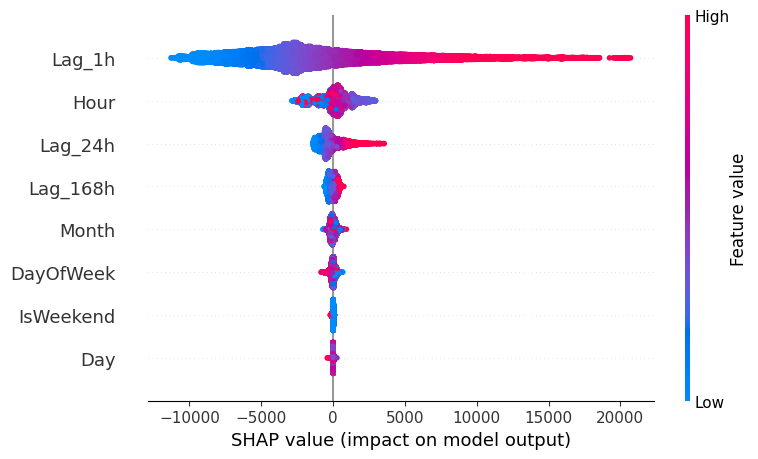

In [175]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=True)

--- Prediction 1 ---
Actual: 29685.00 MW, Predicted: 29847.87 MW


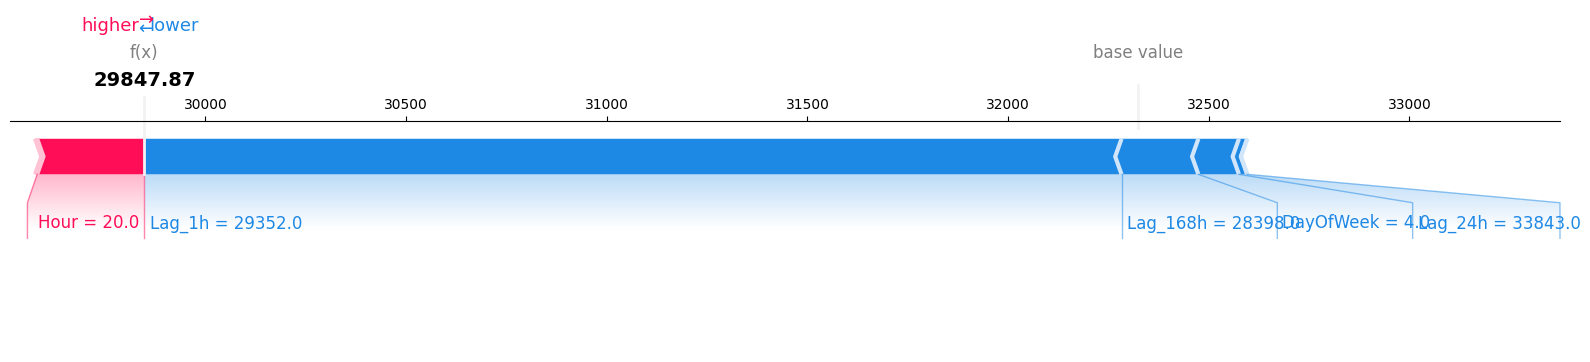

--- Prediction 2 ---
Actual: 30185.00 MW, Predicted: 30312.45 MW


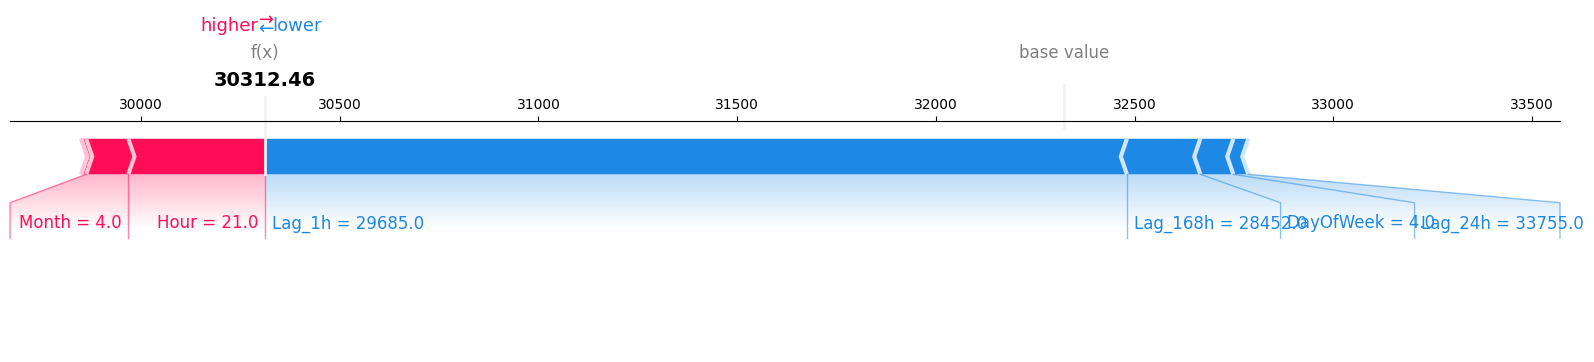

--- Prediction 3 ---
Actual: 29187.00 MW, Predicted: 29504.43 MW


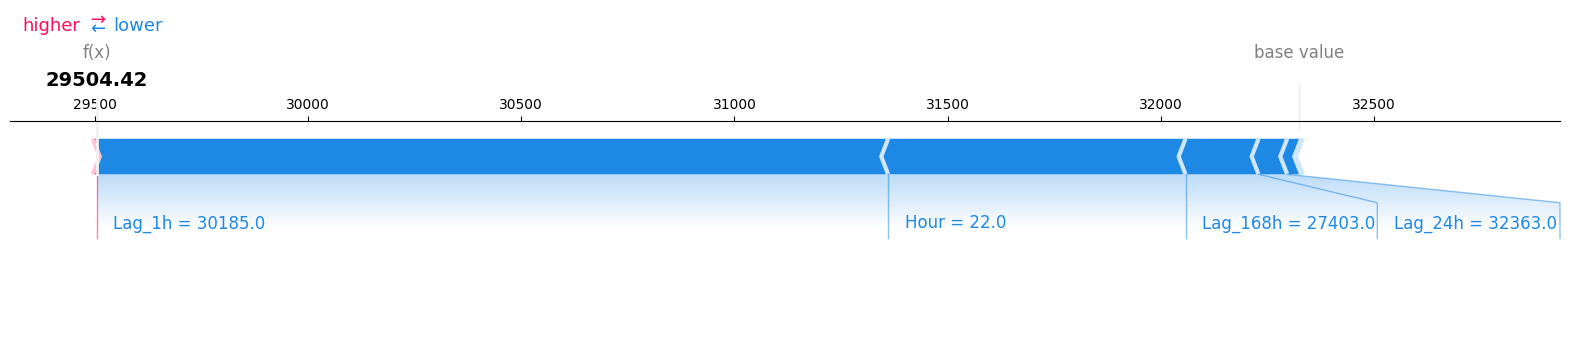

In [176]:
for i in range(3):
  print(f"--- Prediction {i+1} ---")
  print(f"Actual: {y_test.iloc[i]:.2f} MW, Predicted: {y_pred[i]:.2f} MW")
  shap.force_plot(explainer.expected_value, shap_values[i], X_test.iloc[i], matplotlib=True, show=True)

## LIME for LSTM Model

In [177]:
!pip install lime -q
from lime import lime_tabular

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [179]:
X_train_flat = X_train_lstm.reshape(X_train_lstm.shape[0], -1)
X_test_flat = X_test_lstm.reshape(X_test_lstm.shape[0], -1)

lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train_flat,
    mode='regression',
    feature_names=[f"hour_minus_{24-i}" for i in range(24)]
)

exp = lime_explainer.explain_instance(
    X_test_flat[0],
    lambda x: lstm_model.predict(x.reshape(-1, 24, 1)).flatten(),
    num_features=10
)
exp.show_in_notebook()

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [180]:
for i in range(3):
  print(f"--- LSTM Prediction {i+1} ---")
  exp = lime_explainer.explain_instance(
      X_test_flat[i],
      lambda x: lstm_model.predict(x.reshape(-1, 24, 1)).flatten(),
      num_features=10
  )
  exp.show_in_notebook()

--- LSTM Prediction 1 ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


--- LSTM Prediction 2 ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


--- LSTM Prediction 3 ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


## Interpretability Results

SHAP analysis on the XGBoost model shows that Lag_1h (the previous hour's demand) is by far the most important feature, followed by Hour, Lag_24h, and Lag_168h. This matches the intuition that electricity demand has strong short-term momentum.

LIME analysis on the LSTM model shows that the most recent hours in the input window (particularly hour_minus_1 and hour_minus_2) contribute the most to each prediction, which is consistent with the SHAP findings for XGBoost. This agreement between the two interpretability methods adds confidence that both models are learning genuine short-term demand patterns, not spurious correlations.